In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('../data/raw/products.csv')
df.head(30)

,id,language,product,category
0,1,id,laptop Lenovo ThinkPad X1 Carbon Gen 11,IT
1,2,id,PC desktop Dell OptiPlex 7010 Tower,IT
2,3,id,monitor eksternal ASUS ProArt PA278CV,IT
3,4,id,mini PC ASUS ExpertCenter PN64,IT
4,5,id,router Wi-Fi kantor TP-Link Archer AX90 (AX6600),IT
5,6,id,network switch Cisco CBS250-24T-4G,IT
6,7,id,network attached storage (NAS) Synology DiskSt...,IT
7,8,id,printer multi-fungsi HP LaserJet Pro MFP M428fdn,IT
8,9,id,scanner dokumen Epson WorkForce DS-530 II,IT
9,10,id,keyboard wireless Logitech MX Keys S,IT


In [3]:
x = df['product']
y = df['category']

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
vectorizer = TfidfVectorizer()

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [6]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(x_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [7]:
y_pred = model.predict(x_test_tfidf)

In [8]:
results = pd.DataFrame({
    'product': x_test,
    'actual': y_test,
    'predicted': y_pred
})

results

,product,actual,predicted
185,便携式投影仪,IT,IT
33,map tulang ukuran A4,Office Supplies,Office Supplies
58,lampu sorot tanam untuk koridor,Electrical,Electrical
37,buku agenda ukran A5,Office Supplies,IT
79,baut kecil segi enam,Tools & Hardware,Tools & Hardware
124,钢丝钳8寸,Tools & Hardware,IT
103,防降噪耳罩,Safety Equipment,IT
116,复合式洗眼器12L/min,Safety Equipment,IT
106,安全鞋耐200J冲击,Safety Equipment,IT
101,防护眼镜,Safety Equipment,IT


In [9]:
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

      Electrical       1.00      0.38      0.55         8
              IT       0.24      0.88      0.38         8
 Office Supplies       0.75      0.38      0.50         8
Safety Equipment       0.50      0.12      0.20         8
Tools & Hardware       1.00      0.25      0.40         8

        accuracy                           0.40        40
       macro avg       0.70      0.40      0.40        40
    weighted avg       0.70      0.40      0.40        40



In [10]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

cm

array([[3, 4, 0, 1, 0],
       [0, 7, 1, 0, 0],
       [0, 5, 3, 0, 0],
       [0, 7, 0, 1, 0],
       [0, 6, 0, 0, 2]])

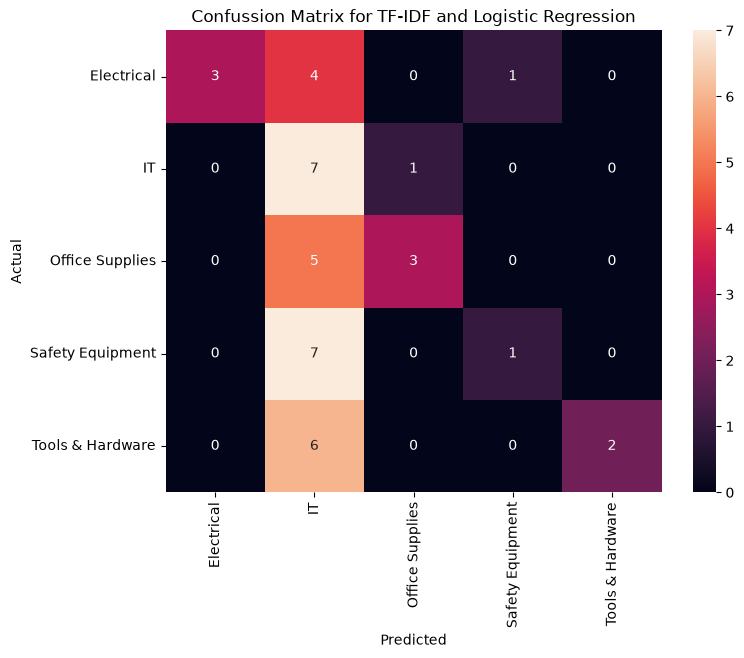

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confussion Matrix for TF-IDF and Logistic Regression')

plt.show()

In [12]:
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f'Baseline Accuracy: {baseline_accuracy:.3f}')

Baseline Accuracy: 0.400


In [13]:
from sklearn.metrics import f1_score

baseline_macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print(f'Baseline Macro-F1： {baseline_macro_f1:.3f}')

Baseline Macro-F1： 0.405
